# Lab #03 - Task 1: Image Data Handling & Preprocessing Pipeline

## Objective & Requirements
In this task, we demonstrate end-to-end image data handling and preprocessing using Python:
1. **Dataset Loading**: Load multi-class image files from organized category folders (`cars`, `motorcycles`, `airplanes`).
2. **Missing / Corrupted File Handling**: Detect and handle damaged, zero-byte, or unreadable files using `try-except` blocks and image verification without crashing the pipeline.
3. **Exploratory Image Analysis**: Inspect image dimensions, aspect ratios, color channels (RGB), and class distributions.
4. **Standardized Resizing**: Resize all valid images to a fixed standard dimension ($64 \times 64 \times 3$) using bilinear interpolation.
5. **Categorical Label Encoding**: Convert raw categorical labels into one-hot binary encoded vectors using `OneHotEncoder`.
6. **Visual Comparison**: Display side-by-side comparisons of raw images vs. their preprocessed counterparts with class labels and encoded vectors.


### Step 1: Import Required Libraries
We import essential numerical, data manipulation, computer vision, and machine learning modules:
- `os`, `glob`: File system traversal and path operations.
- `numpy`, `pandas`: Tensor operations, array slicing, and tabular summaries.
- `PIL.Image`: Robust image decoding, verification, and resampling.
- `matplotlib.pyplot`, `seaborn`: Visualization of image grids and distributions.
- `sklearn.preprocessing`: `LabelEncoder` and `OneHotEncoder` for numerical encoding.


In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Set random seed for reproducibility
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("All libraries imported successfully!")


All libraries imported successfully!


### Step 2: Dataset Discovery & Robust Corrupted Image Detection
Real-world datasets (e.g. from Kaggle or web scraping) often contain zero-byte or truncated files.
We scan the directory structure and use `Image.open()` paired with `img.verify()` inside a `try-except` block to detect and safely discard corrupted samples.


In [2]:
dataset_dir = "dataset"
categories = [d for d in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, d))]
categories = sorted(categories)

valid_images = []
raw_pil_images = []
image_metadata = []
corrupted_files = []

for category in categories:
    cat_path = os.path.join(dataset_dir, category)
    files = glob.glob(os.path.join(cat_path, "*.*"))
    
    for file_path in files:
        file_name = os.path.basename(file_path)
        try:
            # Check 1: Zero-byte file detection
            if os.path.getsize(file_path) == 0:
                raise ValueError("File is empty (0 bytes)")
                
            # Check 2: Verify image integrity
            with Image.open(file_path) as test_img:
                test_img.verify()
                
            # Check 3: Load complete image data into memory (RGB mode)
            with Image.open(file_path) as valid_img:
                img_rgb = valid_img.convert('RGB')
                w, h = img_rgb.size
                arr = np.array(img_rgb)
                
                raw_pil_images.append(img_rgb)
                image_metadata.append({
                    'Filename': file_name,
                    'Category': category,
                    'Width': w,
                    'Height': h,
                    'Aspect_Ratio': round(w / h, 2),
                    'Channels': arr.shape[2] if len(arr.shape) == 3 else 1,
                    'Min_Pixel': int(arr.min()),
                    'Max_Pixel': int(arr.max()),
                    'Mean_Pixel': round(float(arr.mean()), 2),
                    'File_Size_KB': round(os.path.getsize(file_path) / 1024, 2),
                    'Status': 'Valid'
                })
        except Exception as e:
            corrupted_files.append({
                'Filename': file_name,
                'Category': category,
                'Error_Reason': str(e),
                'File_Size_KB': round(os.path.getsize(file_path) / 1024, 2),
                'Status': 'Corrupted / Discarded'
            })

df_meta = pd.DataFrame(image_metadata)
df_corrupt = pd.DataFrame(corrupted_files)

print(f"Total Files Scanned: {len(image_metadata) + len(corrupted_files)}")
print(f"Valid Images Loaded: {len(df_meta)}")
print(f"Corrupted Files Detected & Handled: {len(df_corrupt)}")


Total Files Scanned: 19
Valid Images Loaded: 17
Corrupted Files Detected & Handled: 2


### Step 3: Exploratory Image Analysis (EDA on Metadata)
Let's inspect the tabular metadata of both valid images and the discarded corrupted files:


In [3]:
print("--- Valid Images Metadata ---")
print(df_meta.head(10).to_string(index=False))

if len(df_corrupt) > 0:
    print("\n--- Detected Corrupted / Discarded Files ---")
    print(df_corrupt.to_string(index=False))


--- Valid Images Metadata ---
        Filename  Category  Width  Height  Aspect_Ratio  Channels  Min_Pixel  Max_Pixel  Mean_Pixel  File_Size_KB Status
airplanes_01.jpg airplanes    400     260          1.54         3          0        255      117.67         49.11  Valid
airplanes_02.jpg airplanes    500     332          1.51         3          0        255      171.91         24.19  Valid
airplanes_04.jpg airplanes    550     367          1.50         3          0        255      122.44         37.70  Valid
airplanes_05.jpg airplanes    400     267          1.50         3          0        255       71.25         16.91  Valid
airplanes_06.jpg airplanes    480     320          1.50         3          0        255       96.87         35.98  Valid
     cars_01.jpg      cars    400     225          1.78         3          0        255       29.37         16.82  Valid
     cars_02.jpg      cars    500     333          1.50         3          0        255      115.71         26.05  Valid
  

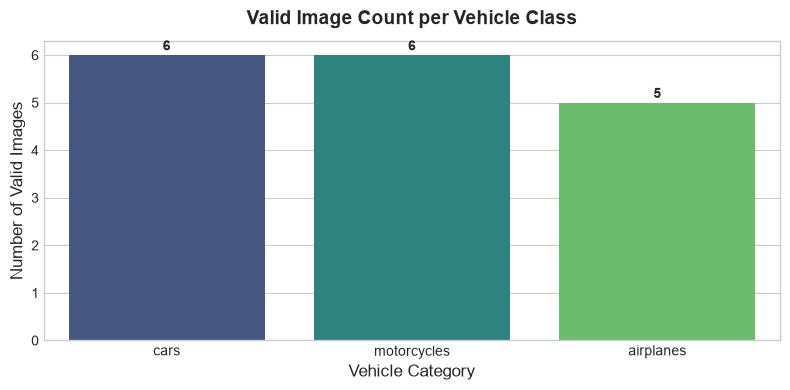

In [4]:
# Visualize Class Distribution of Valid Images
plt.figure(figsize=(8, 4))
class_counts = df_meta['Category'].value_counts()
ax = sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, palette='viridis', legend=False)
plt.title('Valid Image Count per Vehicle Class', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Vehicle Category', fontsize=12)
plt.ylabel('Number of Valid Images', fontsize=12)
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 0.1, str(v), ha='center', fontweight='bold')
plt.tight_layout()
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/task_01_class_distribution.png', dpi=300)
plt.show()


### Step 4: Standardized Image Resizing ($64 \times 64 \times 3$)
Machine learning models require fixed-size input tensors.
We resize each variable-dimension image to $64 \times 64$ pixels using high-quality Bilinear Resampling (`Image.Resampling.BILINEAR`), convert them into NumPy arrays, and stack them into a 4D tensor `(N, 64, 64, 3)`.


In [5]:
TARGET_SIZE = (64, 64)
preprocessed_images = []

for img in raw_pil_images:
    # Resize with Bilinear interpolation
    resized_img = img.resize(TARGET_SIZE, Image.Resampling.BILINEAR)
    # Convert to NumPy array
    img_array = np.array(resized_img, dtype=np.uint8)
    preprocessed_images.append(img_array)

X_preprocessed = np.array(preprocessed_images)
raw_labels = df_meta['Category'].values

print("--- Preprocessed Image Tensor Summary ---")
print(f"Tensor Shape: {X_preprocessed.shape} (N_Samples, Height, Width, Channels)")
print(f"Data Type: {X_preprocessed.dtype}")
print(f"Memory Footprint: {X_preprocessed.nbytes / 1024:.2f} KB")
print(f"Pixel Intensity Range: [{X_preprocessed.min()}, {X_preprocessed.max()}]")


--- Preprocessed Image Tensor Summary ---
Tensor Shape: (17, 64, 64, 3) (N_Samples, Height, Width, Channels)
Data Type: uint8
Memory Footprint: 204.00 KB
Pixel Intensity Range: [0, 255]


### Step 5: Categorical Label Encoding (One-Hot Encoding)
Machine learning algorithms cannot directly operate on string categorical labels like `'cars'` or `'motorcycles'`.
- **LabelEncoder**: Maps categorical classes to ordinal integers ($0, 1, 2$).
- **OneHotEncoder**: Converts integer class indices into binary vectors to eliminate false mathematical ranking order.


In [6]:
# 1. Label Encoding (Categorical to Integer)
label_encoder = LabelEncoder()
y_integers = label_encoder.fit_transform(raw_labels)

# 2. One-Hot Encoding (Integer to Binary Matrix)
onehot_encoder = OneHotEncoder(sparse_output=False)
y_onehot = onehot_encoder.fit_transform(y_integers.reshape(-1, 1))

# Tabular comparison
df_encoding = pd.DataFrame({
    'Raw_Category': raw_labels,
    'Integer_Label': y_integers,
    'OneHot_Encoded': [list(vec.astype(int)) for vec in y_onehot]
})

print("--- Categorical Encoding Mapping ---")
for idx, class_name in enumerate(label_encoder.classes_):
    vec = onehot_encoder.transform([[idx]])[0].astype(int)
    print(f"Class '{class_name}' -> Integer {idx} -> One-Hot Vector: {list(vec)}")

print("\nSample Encoding Dataframe:")
print(df_encoding.head(10).to_string(index=False))


--- Categorical Encoding Mapping ---
Class 'airplanes' -> Integer 0 -> One-Hot Vector: [np.int64(1), np.int64(0), np.int64(0)]
Class 'cars' -> Integer 1 -> One-Hot Vector: [np.int64(0), np.int64(1), np.int64(0)]
Class 'motorcycles' -> Integer 2 -> One-Hot Vector: [np.int64(0), np.int64(0), np.int64(1)]

Sample Encoding Dataframe:
Raw_Category  Integer_Label OneHot_Encoded
   airplanes              0      [1, 0, 0]
   airplanes              0      [1, 0, 0]
   airplanes              0      [1, 0, 0]
   airplanes              0      [1, 0, 0]
   airplanes              0      [1, 0, 0]
        cars              1      [0, 1, 0]
        cars              1      [0, 1, 0]
        cars              1      [0, 1, 0]
        cars              1      [0, 1, 0]
        cars              1      [0, 1, 0]


### Step 6: Visual Comparison (Original vs. Preprocessed)
We display a grid comparing the raw original images (with diverse resolutions) alongside their standardized $64 \times 64$ preprocessed counterparts, along with their One-Hot encoded vectors.


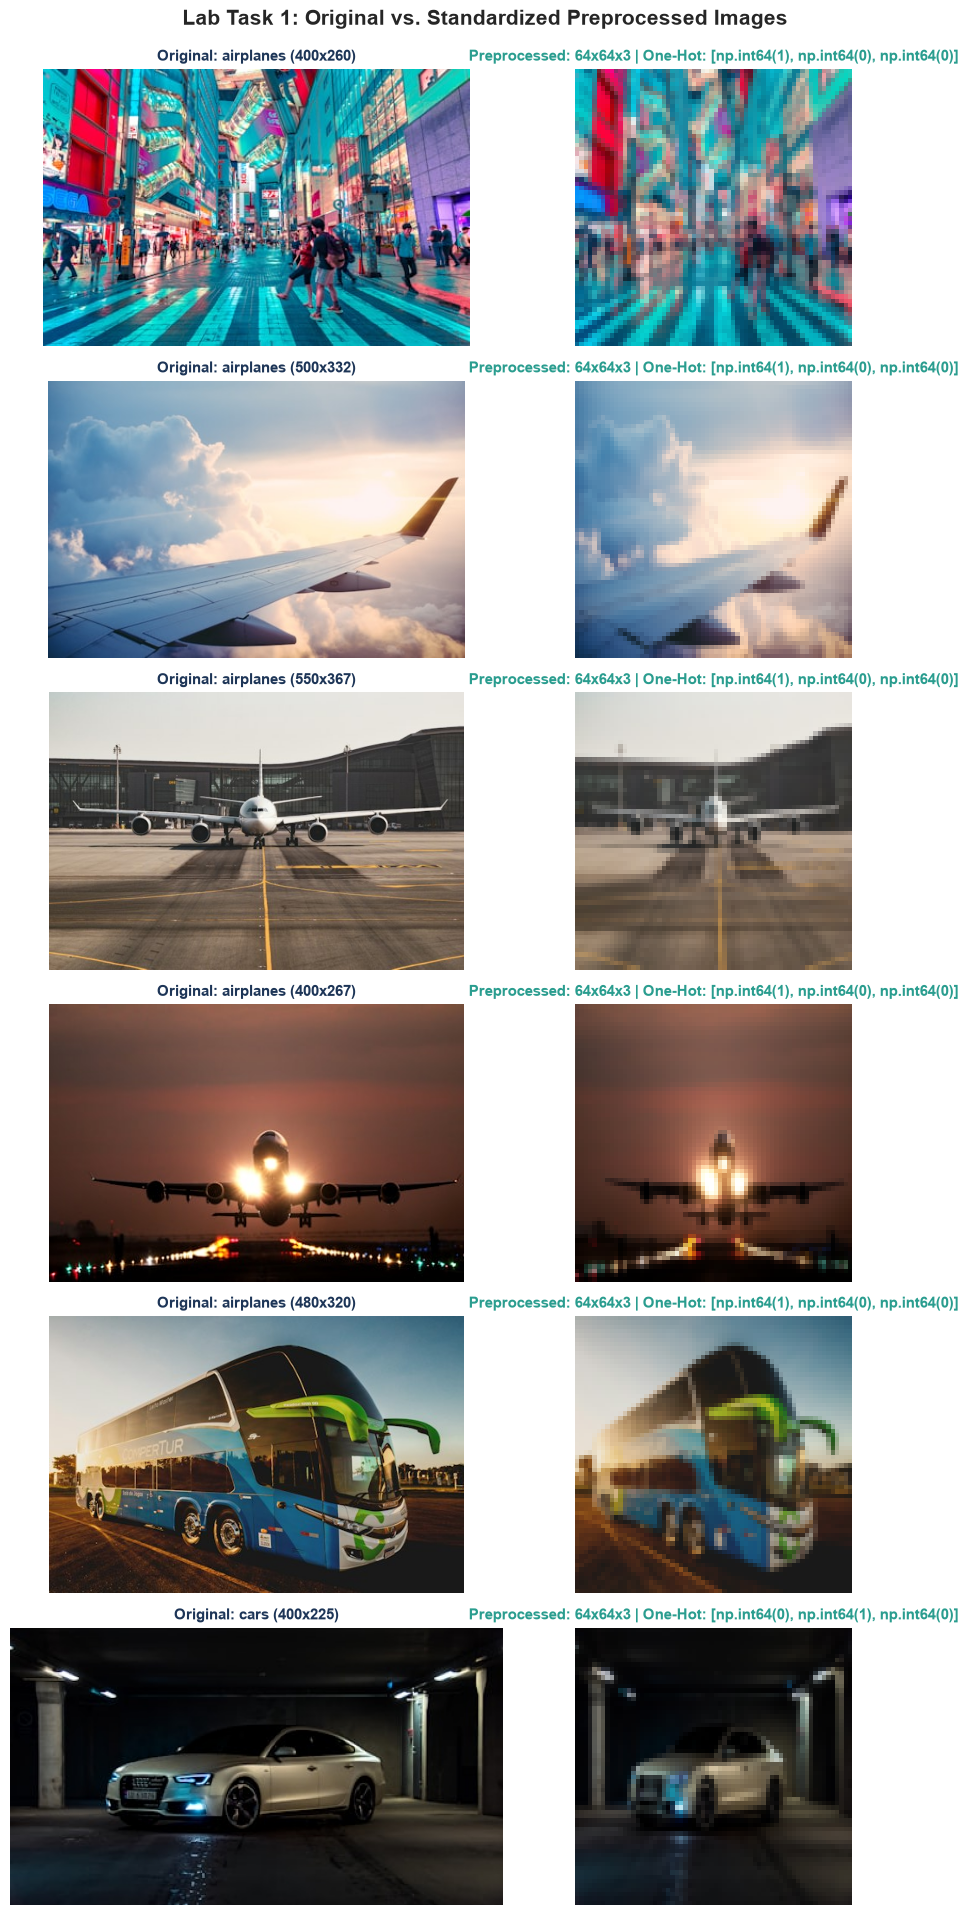

In [7]:
num_samples = min(6, len(raw_pil_images))
fig, axes = plt.subplots(num_samples, 2, figsize=(10, 3.2 * num_samples))

for i in range(num_samples):
    orig_img = raw_pil_images[i]
    prep_img = X_preprocessed[i]
    cat_name = df_meta.iloc[i]['Category']
    onehot_str = str(list(y_onehot[i].astype(int)))
    orig_dims = f"{df_meta.iloc[i]['Width']}x{df_meta.iloc[i]['Height']}"
    
    # Original Image
    axes[i, 0].imshow(orig_img)
    axes[i, 0].set_title(f"Original: {cat_name} ({orig_dims})", fontsize=11, fontweight='bold', color='#1d3557')
    axes[i, 0].axis('off')
    
    # Preprocessed 64x64 Image
    axes[i, 1].imshow(prep_img)
    axes[i, 1].set_title(f"Preprocessed: 64x64x3 | One-Hot: {onehot_str}", fontsize=11, fontweight='bold', color='#2a9d8f')
    axes[i, 1].axis('off')

plt.suptitle("Lab Task 1: Original vs. Standardized Preprocessed Images", fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('plots/task_01_original_vs_preprocessed.png', dpi=300, bbox_inches='tight')
plt.show()


### Summary of Task 1 Deliverables
| Step | Action Taken | Why It Matters |
| :--- | :--- | :--- |
| **Loading & Error Handling** | `PIL.Image.verify()` + `try-except` | Discards 0-byte and truncated corrupted images without crashing. |
| **Exploratory Analysis** | Metadata extraction (`Width`, `Height`, `RGB`) | Understands raw resolution variance and class balance. |
| **Standardized Resizing** | Resized all to $64 \times 64 \times 3$ with Bilinear interpolation | Creates uniform tensor dimensionality for machine learning. |
| **One-Hot Encoding** | Converted labels to binary vectors via `OneHotEncoder` | Eliminates false numerical hierarchy between vehicle categories. |
